In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM



In [26]:
##load code

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/energy_data.csv")

# Clean
df.fillna(0, inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
##convert timestamp

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df = df.sort_index()

In [ ]:
##create time features

In [4]:
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['weekday'] = df.index.dayofweek

In [5]:
print(df.columns)

Index(['fridge', 'ac', 'lights', 'microwave', 'total_power', 'hour', 'day',
       'month', 'weekday'],
      dtype='str')


In [6]:
df['lag_1'] = df['total_power'].shift(1)
df['lag_24'] = df['total_power'].shift(24)

df['rolling_mean_24'] = df['total_power'].rolling(24).mean()
df['rolling_std_24'] = df['total_power'].rolling(24).std()

In [36]:
df.dropna(inplace=True)

In [37]:
hourly = df.groupby('hour')['total_power'].mean()
print(hourly)

hour
0     1101.955556
1     1043.525140
2     1076.703911
3     1058.737430
4     1051.072626
5     1011.821229
6     1077.592179
7     1029.865922
8      990.547486
9      953.072626
10     983.849162
11    1000.407821
12     917.212291
13     918.223464
14    1056.748603
15    1005.044693
16     924.882682
17     913.687151
18     892.189944
19    1030.837989
20    1074.061453
21    1122.558659
22    1098.558659
23    1061.547486
Name: total_power, dtype: float64


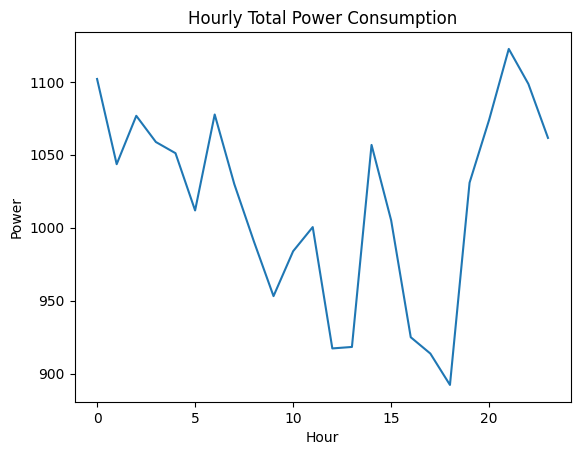

In [38]:
plt.figure()
hourly.plot(title="Hourly Total Power Consumption")
plt.xlabel("Hour")
plt.ylabel("Power")
plt.show()

In [ ]:
##train test split

In [8]:
features = ['fridge','ac','lights','microwave','hour','day','month','lag_1','lag_24','rolling_mean_24']

X = df[features]
y = df['total_power']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)


In [ ]:
##linear regression

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [ ]:
##performance , metrics

In [12]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 7.335797688466165e-13
RMSE: 9.036667024582114e-13
R2 Score: 1.0


In [ ]:
## actual vs predicted

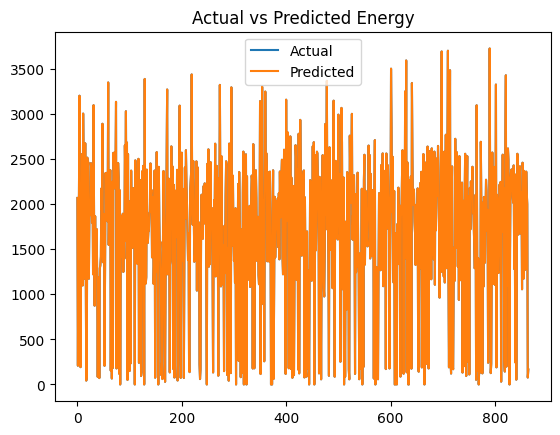

In [13]:
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Actual vs Predicted Energy")
plt.legend()
plt.show()


In [15]:
coeff = pd.Series(model.coef_, index=features)
print("\nLinear Regression Coefficients:\n", coeff)


Linear Regression Coefficients:
 fridge             1.000000e+00
ac                 1.000000e+00
lights             1.000000e+00
microwave          1.000000e+00
hour              -4.524159e-15
day               -1.950697e-15
month              1.769684e-13
lag_1              1.110223e-16
lag_24            -1.387779e-16
rolling_mean_24    1.110223e-16
dtype: float64


In [ ]:
##residual analysis

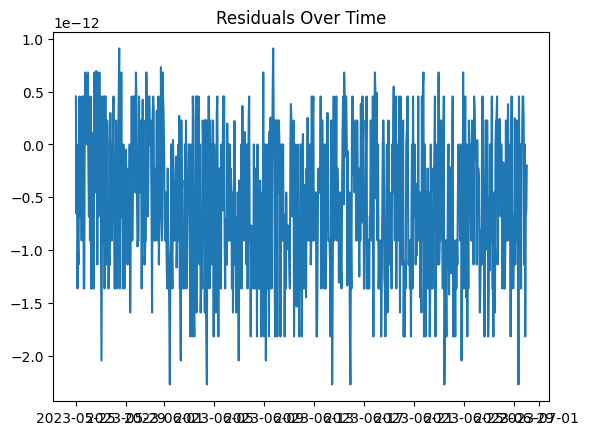

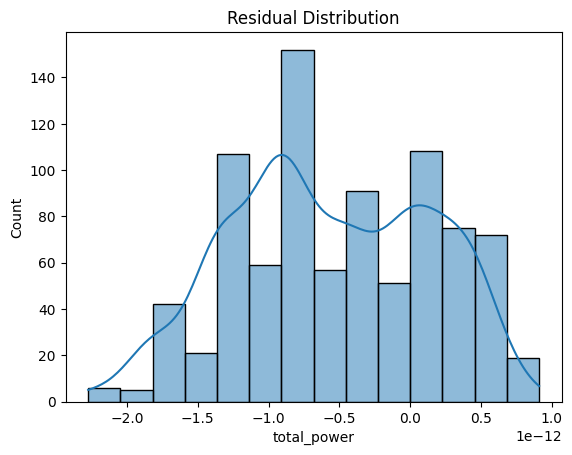

In [16]:
residuals = y_test - y_pred

# Residual over time
plt.figure()
plt.plot(residuals)
plt.title("Residuals Over Time")
plt.show()

# Distribution
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


In [ ]:
##actual vs 24h rolling mean

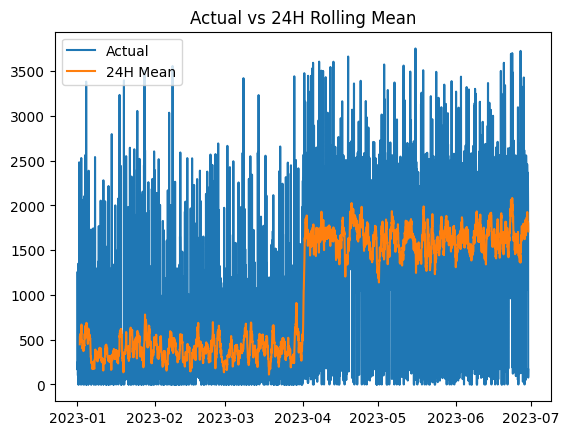

In [17]:
plt.figure()
plt.plot(df['total_power'], label="Actual")
plt.plot(df['rolling_mean_24'], label="24H Mean")
plt.legend()
plt.title("Actual vs 24H Rolling Mean")
plt.show()

In [ ]:
##rolling volatility

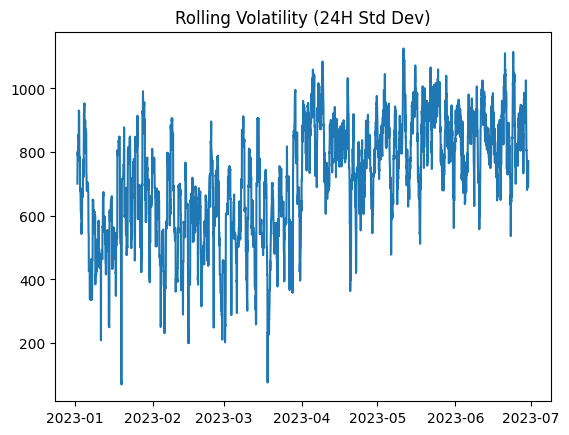

In [19]:
plt.figure()
plt.plot(df['rolling_std_24'])
plt.title("Rolling Volatility (24H Std Dev)")
plt.show()

In [ ]:
##shannon entropy

In [20]:
def shannon_entropy(series):
    probs = series.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs + 1e-9))

entropy = shannon_entropy(df['total_power'].round())
print("Shannon Entropy:", entropy)


Shannon Entropy: 9.78253573183541


In [ ]:
##anomaly detection

In [21]:
def hurst(ts):
    lags = range(2, 20)
    tau = [np.std(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]*2

hurst_val = hurst(df['total_power'].values)
print("Hurst Exponent:", hurst_val)


Hurst Exponent: 0.006794692440851676


In [ ]:
##one-class sum

In [22]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df[['total_power']])

svm = OneClassSVM(nu=0.05, kernel="rbf", gamma='auto')
df['svm_anomaly'] = svm.fit_predict(scaled)

svm_anomalies = df[df['svm_anomaly'] == -1]
print("Number of One-Class SVM Anomalies:", len(svm_anomalies))

Number of One-Class SVM Anomalies: 463
